<a href="https://colab.research.google.com/github/DJCordhose/buch-machine-learning-notebooks/blob/master/kap11-train.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Datenbasierter Ansatz


In [1]:
import pandas as pd
import numpy as np

In [2]:
import matplotlib.pyplot as plt
%matplotlib inline

import matplotlib as mpl
mpl.rcParams['figure.figsize'] = (20, 8)
mpl.rcParams['axes.titlesize'] = 24
mpl.rcParams['axes.labelsize'] = 16

In [3]:
import sys
IN_COLAB = 'google.colab' in sys.modules
IN_COLAB

False

### Daten holen und lokal speichern

In [ ]:
# Wir laden hier auch gleich die Daten, die 
# im zweiten Notebook benötigt werden, um die Drift zu 
# berechnen. Dort gehen wir einfach davon aus, dass sie
# schon existieren. Also nicht wundern. ;)

# TODO: Nur neu holen, wenn die Daten noch nicht lokal vorhanden sind.

from pathlib        import Path
from urllib.request import urlopen, urlretrieve
import json

BASE_DIR    = Path("./datasets/insurance_prediction")
MONTHLY_DIR = BASE_DIR / "monthly"

BASE_RAW_URL = (
    "https://raw.githubusercontent.com/"
    "DJCordhose/ml-for-business/main/"
    "datasets/insurance_prediction/"
)

MONTHLY_API_URL = (
    "https://api.github.com/repos/"
    "DJCordhose/ml-for-business/contents/"
    "datasets/insurance_prediction/monthly?ref=main"
)


def is_monthly_dataset(file_info: dict) -> bool:
    return (
        file_info.get("type") == "file"
        and file_info.get("name", "").startswith("month-")
        and file_info.get("name", "").endswith(".csv.gz")
    )


def month_number(file_info: dict) -> int:
    name = file_info["name"]
    return int(name.removeprefix("month-").removesuffix(".csv.gz"))


BASE_DIR.mkdir(parents=True, exist_ok=True)
MONTHLY_DIR.mkdir(parents=True, exist_ok=True)

urlretrieve(
    f"{BASE_RAW_URL}reference.csv.gz",
    BASE_DIR / "reference.csv.gz",
)

with urlopen(MONTHLY_API_URL) as response:
    files = json.load(response)

monthly_files = sorted(
    (file_info for file_info in files if is_monthly_dataset(file_info)),
    key=month_number,
)

for file_info in monthly_files:
    urlretrieve(
        file_info["download_url"],
        MONTHLY_DIR / file_info["name"],
    )

### old Code still working
### might consolidate in future

def url_for_dataset(relative_path):
  if IN_COLAB:
    url = f'https://github.com/DJCordhose/ml-for-business/raw/main/datasets/insurance_prediction/{relative_path}.csv.gz'
  else:
    url =  f'./datasets/insurance_prediction/{relative_path}.csv.gz'
  return url

# Schritt 0: Kann das überhaupt klappen?

## Anforderungen
- 150$ Profit pro Antrag!
- Mindestens 1/3 aller Anträge bekommen eine Versicherung

In [5]:
minimun_insurance_rate =  1/3
mimimum_profit_per_case = 150

## Annahmen

![](https://github.com/DJCordhose/ml-for-business/blob/main/img/kpi_matrix.jpg?raw=1)

- **Richtig Positive** würden jeweils einen Gewinn von \$1.000 erzeugen, weil es sich um Kunden handelt, die korrekt als gute Risiken identifiziert wurden, was zu profitablen Geschäften führt.
- **Falsch Positive** würden jeweils \$5.000 kosten, weil es sich um Fälle handelt, bei denen das Geschäft durch Ansprüche, die die Prämien übersteigen, verloren geht.
- **Falsch Negative** würden jeweils \$1.000 kosten und den verlorenen Gewinn aus einem guten Kunden darstellen, der fälschlicherweise abgewiesen wurde.
- **Richtig Negative** erzeugen keinen direkten Umsatz (da keine Versicherungspolice ausgestellt wird), haben jedoch eine positive finanzielle Auswirkung, indem potenzielle Kosten vermieden werden, allerdings ist es schwieriger, einen direkten monetären Wert zuzuweisen, daher wird dies hier nicht berücksichtigt.

Das Ziel ist es, die Anzahl der richtig positiven Fälle zu maximieren und gleichzeitig die Anzahl der falsch positiven und falsch negativen Fälle zu minimieren.



https://en.wikipedia.org/wiki/Precision_and_recall

1. **Richtig Positiv (tp)**: Die Anzahl der Fälle, in denen der Klassifikator korrekt vorhergesagt hat, dass einem Kunden eine Versicherung gewährt werden sollte (d.h., der Kunde war ein gutes Risiko und der Klassifikator sagte 'ja').

2. **Falsch Positiv (fp)**: Die Anzahl der Fälle, in denen der Klassifikator fälschlicherweise vorhergesagt hat, dass einem Kunden eine Versicherung gewährt werden sollte (d.h., der Kunde war tatsächlich ein schlechtes Risiko, aber der Klassifikator sagte 'ja'). Dies ist kostspielig, da es einen Verlust für das Unternehmen darstellt, weil Versicherungsansprüche zu leisten sind.

3. **Richtig Negativ (tn)**: Die Anzahl der Fälle, in denen der Klassifikator korrekt vorhergesagt hat, dass einem Kunden keine Versicherung gewährt werden sollte (d.h., der Kunde war ein schlechtes Risiko und der Klassifikator sagte 'nein').

4. **Falsch Negativ (fn)**: Die Anzahl der Fälle, in denen der Klassifikator fälschlicherweise vorhergesagt hat, dass einem Kunden keine Versicherung gewährt werden sollte (d.h., der Kunde war tatsächlich ein gutes Risiko, aber der Klassifikator sagte 'nein'). Dies stellt eine verpasste Gelegenheit dar, bei der das Unternehmen Geschäft von einem guten Kunden verpasst.


In [6]:
# costs and benefits
cost_fp   = 5_000  # cost of a false positive
reward_tp = 1000  # reward of a true positive
cost_fn   = 1000  # cost of a false negative

## Wir machen Annahmen für die Verteilung der Fälle

In [7]:
# das ist total aus den Fingern gesaugt, könnte aber auch anhand von allgemeinen Statistiken ermittelt werden
tn, fn, fp, tp = 45, 5, 5, 45

In [8]:
all_cases = tn + fp + fn + tp

In [9]:
rate_people_getting_insurance = (tp + fp) / all_cases
rate_people_getting_insurance

0.5

In [10]:
assert rate_people_getting_insurance > minimun_insurance_rate

In [11]:
kpi = (tp * reward_tp) - (fp * cost_fp) - (fn * cost_fn)
kpi_per_case = round(kpi  / all_cases)

print(f"KPI: ${kpi_per_case}")

KPI: $150


In [12]:
# kommen wir zumindest in die Nähe?
assert kpi_per_case >= mimimum_profit_per_case

# Schritt 1: Daten laden und sichten

Das kann also hinkommen. Für jeden weiteren Schritt brauchen wir Daten

In [13]:
df = pd.read_csv(url_for_dataset(f'reference'), delimiter=';')
df.head()

,training,age,emergency_braking,braking_distance,power,milage,risk,group_name,group,good_customer
0,0,41.951100,0,40.933328,122.238329,98.509765,3.705528,high,0,0
1,0,24.368286,1,44.797317,113.765298,46.324178,2.442419,medium,1,0
2,0,18.314649,1,41.587241,143.427269,76.862968,4.074379,high,0,0
3,0,51.265254,1,47.266716,111.578133,102.697069,5.093286,high,0,0
4,0,23.578861,0,42.835319,145.994235,63.690055,3.733844,high,0,0


## Die Referenz für die Vorhersage

In [14]:
y = df['good_customer'].values  # binary classification
np.unique(y, return_counts=True)

(array([0, 1]), array([845, 655]))

In [15]:
# wir brauchen nur die binäre Vorhersage, die haben wir aber jetzt schon in y
df = df.drop(['risk', 'group', 'group_name', 'good_customer'], axis='columns')
df = df.round(1)
df

,training,age,emergency_braking,braking_distance,power,milage
0,0,42.0,0,40.9,122.2,98.5
1,0,24.4,1,44.8,113.8,46.3
2,0,18.3,1,41.6,143.4,76.9
3,0,51.3,1,47.3,111.6,102.7
4,0,23.6,0,42.8,146.0,63.7
...,...,...,...,...,...,...
1495,0,18.4,0,43.3,116.6,75.5
1496,0,58.7,0,40.9,184.0,135.2
1497,0,19.1,0,28.6,74.5,66.0
1498,0,42.6,0,33.0,118.8,61.9


## Unsere Eigenschaften

* age, numerisch: Das Alter der/des Versicherten
* milage, numerisch: Wie viel tausend Kilometer werden pro Jahr gefahren
* training, binär: Hat die/der Versicherte ein spezielles Sicherheitstraining absolviert?
* power, numerisch: Leistung des versicherten Fahrzeugs in Kilowatt
* braking_distance, numerisch: Bremsweg aus 100 km/h in Metern
* emergency_braking: binär: Hat das versicherte Fahrzeug Assistenz-Systeme, wie zum Beispiel ein Notbremssystem?


## Reduzieren auf wichtige Daten (als mögliche Reaktion auf drift)

_Vorsicht_: Wenn Features komplett fehlen, müssen auch die regelbasierten Baselines angepasst werden

In [16]:
# comment in or even add more dropped features

def drop_unimportant_features(df):
    # in the future we will only see samples with emergency braking
    # df = df[df['emergency_braking'] == 1]
    # drop features that no longer have a significant impact on prediction to avoid overfitting
    # df.drop(['emergency_braking'], axis='columns', inplace=True)
    return df

In [17]:
df = drop_unimportant_features(df)

In [18]:
df.describe()

,training,age,emergency_braking,braking_distance,power,milage
count,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000
mean,0.210000,35.147067,0.394000,39.904200,134.888867,80.965600
std,0.407444,12.766633,0.488798,4.781219,35.047779,25.497642
min,0.000000,15.900000,0.000000,24.400000,38.200000,18.800000
25%,0.000000,25.100000,0.000000,36.700000,110.000000,62.675000
50%,0.000000,32.700000,0.000000,39.900000,131.050000,77.100000
75%,0.000000,42.600000,1.000000,42.900000,157.300000,95.600000
max,1.000000,86.200000,1.000000,56.500000,285.800000,211.800000


## Einen Teil der Daten nutzen wir zum Training und einen anderen zur Überprüfung

* das machen wir hier unabhängig von der Zeit der Erhebung der Daten
* Alternative: nur die neuesten Daten zur Überprüfung nehmen und mit älteren trainieren, um zu schauen, ob das Modell von der Vergangenheit in die Zukunft vorhersagen kann
* Nachteile
  - wir nutzen die neuesten Daten nicht für das Training
  - Vorteil fraglich, da wir immer noch nicht wissen, ob das Modell für die tatsächliche Zukunft taugt
* Stattdessen eher: Analysen über den Verlauf machen  

In [19]:
X = df.values

In [20]:
from sklearn.model_selection import train_test_split
X = df.values
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=21, stratify=y)
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((1200, 6), (300, 6), (1200,), (300,))

# Schritt 2: Regelbasierter Ansatz

- reicht das vielleicht schon? erreichen wir damit unsere Vorgaben?
- zumindest Baseline
- technische Metrik ist Accuracy: einfach - wie viele Vorhersagen stimmen

In [21]:
class ClassifierBase:
    def predict(self, X):
        return np.array([ self.predict_single(x) for x in X])
    def score(self, X, y):
        n = len(y)
        correct = 0
        predictions = self.predict(X)
        for prediction, ground_truth in zip(predictions, y):
            if prediction == ground_truth:
                correct = correct + 1
        return correct / n

In [22]:
from random import randrange

class RandomClassifier(ClassifierBase):
    def predict_single(self, x):
        return randrange(0, 2)
base_clf = RandomClassifier()
base_clf.score(X_test, y_test)

0.54

In [23]:
# just return most frequent value might be a baseline
np.unique(y_test, return_counts=True)

(array([0, 1]), array([169, 131]))

In [24]:
class NaiveClassifier(ClassifierBase):
    def predict_single(self, x):
        return 0
base_clf = NaiveClassifier()
base_clf.score(X_test, y_test)

0.5633333333333334

In [25]:
class BaseLineClassifier(ClassifierBase):
    def predict_single(self, x):
        training, age, emergency_braking, braking_distance, power, milage = x
        if training:
            return 1
        if age < 30:
            if power > 100:
                return 0
        if age > 55:
            return 0
        if emergency_braking:
            return 1
        if milage > 50:
            return 0
        # default
        return 0
base_clf = BaseLineClassifier()
base_clf.score(X_test, y_test)

0.7733333333333333

## Bewertung anhand von Business KPIs

In [26]:
from sklearn.metrics import confusion_matrix

y_true = y_test
threshold = .5
y_pred = (base_clf.predict(X_test) > threshold).astype("int32")
tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
tn, fp, fn, tp

(np.int64(143), np.int64(26), np.int64(42), np.int64(89))

In [27]:
rate_people_getting_insurance = (tp + fp) / len(y_test)
rate_people_getting_insurance

np.float64(0.38333333333333336)

In [28]:
rate_people_getting_insurance > minimun_insurance_rate

np.True_

In [29]:
kpi = (tp * reward_tp) - (fp * cost_fp) - (fn * cost_fn)
kpi_per_case = round(kpi  / len(y_true))

print(f"KPI: ${kpi_per_case}")

KPI: $-277


In [30]:
kpi_per_case >= mimimum_profit_per_case

False

# Schritt 3: Trainiertes Modell

In [ ]:
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader, random_split

torch.__version__

'2.11.0'

In [32]:
# je mehr Bums desto besser
# Standard: Colab/CUDA
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(42)
    os.system("nvidia-smi")
    device = torch.device("cuda")  # NVIDIA/Colab
# Sonderfall: Mac mit Apple Silicon:
elif torch.backends.mps.is_available():
    device = torch.device("mps")   # Apple Silicon GPU
# Fallback: CPU
else:
    device = torch.device("cpu")

print(device)

mps


In [33]:
# Reproduzierbarkeit ist hier wichtiger als maximale Trainingsgeschwindigkeit:
# Die Assertions im Notebook sollen nicht zufällig einmal bestehen und einmal fehlschlagen.
torch.manual_seed(42)
np.random.seed(42)

In [34]:
# Keras konnte die Normalisierung als Layer adaptieren. In PyTorch ist es idiomatisch,
# Mittelwert und Standardabweichung aus den Trainingsdaten zu berechnen und als Buffer
# im Modell zu registrieren. Buffer werden mit dem Modell gespeichert und auf das Device
# verschoben, sind aber keine trainierbaren Gewichte.
X_train_tensor_for_stats = torch.tensor(X_train, dtype=torch.float32)
feature_mean             = X_train_tensor_for_stats.mean(dim=0)
feature_std              = X_train_tensor_for_stats.std(dim=0).clamp_min(1e-6)
feature_mean, feature_std

(tensor([  0.2108,  35.2079,   0.3992,  39.9553, 135.6294,  80.8693]),
 tensor([ 0.4081, 12.9619,  0.4899,  4.8115, 35.0544, 25.2691]))

In [35]:
# Modell definieren
class Normalization(nn.Module):
    def __init__(self, mean, std):
        super().__init__()

        self.register_buffer("mean", mean)
        self.register_buffer("std", std)

    def forward(self, x):
        return (x - self.mean) / self.std


class BinaryClassifier(nn.Module):
    def __init__(self, num_features, feature_mean, feature_std,
                 neurons_per_layer=100, dropout=0.7):
        super().__init__()

        # Sigmoid steht bewusst nicht im Modell, weil BCEWithLogitsLoss numerisch
        # stabiler mit rohen Logits arbeitet.
        self.network = nn.Sequential(
            Normalization(feature_mean, feature_std),

            nn.Linear(num_features, neurons_per_layer),
            nn.ReLU(),
            nn.BatchNorm1d(neurons_per_layer),
            nn.Dropout(dropout),

            nn.Linear(neurons_per_layer, neurons_per_layer),
            nn.ReLU(),
            nn.BatchNorm1d(neurons_per_layer),
            nn.Dropout(dropout),

            nn.Linear(neurons_per_layer, 1),
        )

    def forward(self, x):
        # Die letzte Dimension wird entfernt, damit die Modell-Ausgabe dieselbe Form
        # wie die Label-Vektoren und die nachfolgenden Auswertungen im Notebook hat.
        return self.network(x).squeeze(-1)


num_features      = X_train.shape[1]
dropout           = 0.7
neurons_per_layer = 100

model = BinaryClassifier(
    num_features=num_features,
    feature_mean=feature_mean,
    feature_std=feature_std,
    neurons_per_layer=neurons_per_layer,
    dropout=dropout,
).to(device)

model

BinaryClassifier(
  (network): Sequential(
    (0): Normalization()
    (1): Linear(in_features=6, out_features=100, bias=True)
    (2): ReLU()
    (3): BatchNorm1d(100, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (4): Dropout(p=0.7, inplace=False)
    (5): Linear(in_features=100, out_features=100, bias=True)
    (6): ReLU()
    (7): BatchNorm1d(100, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (8): Dropout(p=0.7, inplace=False)
    (9): Linear(in_features=100, out_features=1, bias=True)
  )
)

In [36]:
# Modellbeschreibung ausgeben:
from torchinfo import summary
summary(
    model,
    input_size=(1, 6),
    depth=10,
    col_names=("input_size", "output_size"),
)

Layer (type:depth-idx)                   Input Shape               Output Shape
BinaryClassifier                         [1, 6]                    [1]
├─Sequential: 1-1                        [1, 6]                    [1, 1]
│    └─Normalization: 2-1                [1, 6]                    [1, 6]
│    └─Linear: 2-2                       [1, 6]                    [1, 100]
│    └─ReLU: 2-3                         [1, 100]                  [1, 100]
│    └─BatchNorm1d: 2-4                  [1, 100]                  [1, 100]
│    └─Dropout: 2-5                      [1, 100]                  [1, 100]
│    └─Linear: 2-6                       [1, 100]                  [1, 100]
│    └─ReLU: 2-7                         [1, 100]                  [1, 100]
│    └─BatchNorm1d: 2-8                  [1, 100]                  [1, 100]
│    └─Dropout: 2-9                      [1, 100]                  [1, 100]
│    └─Linear: 2-10                      [1, 100]                  [1, 1]
Total params: 11,30

In [37]:
# %%time

BATCH_SIZE = 32
# BATCH_SIZE = 64
EPOCHS = 75

X_train_t = torch.tensor(X_train, dtype=torch.float32)
y_train_t = torch.tensor(y_train, dtype=torch.float32)

# Wir teilen den TensorDataset mit festem Seed, damit die Kurven stabil bleiben.
train_val_dataset = TensorDataset(X_train_t, y_train_t)
val_size          = int(len(train_val_dataset) * 0.2)
train_size        = len(train_val_dataset) - val_size
generator         = torch.Generator().manual_seed(42)
train_dataset, val_dataset = (
        random_split(train_val_dataset, 
        [train_size, val_size], 
        generator=generator)
    ) 

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, generator=generator)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE)

loss_fn   = nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(model.parameters())


def evaluate_model(model, loader):
    # Evaluation ist eine eigene Funktion, damit dieselbe Logik für Validierung,
    # Training und Test verwendet wird. Das reduziert stille Abweichungen zwischen Metriken.
    model.eval()
    total_loss = 0.0
    correct    = 0
    total      = 0

    with torch.no_grad():
        for X_batch, y_batch in loader:
            X_batch       = X_batch.to(device)
            y_batch       = y_batch.to(device)
            logits        = model(X_batch)
            loss          = loss_fn(logits, y_batch)
            total_loss   += loss.item() * len(y_batch)
            probabilities = torch.sigmoid(logits)
            predictions   = (probabilities > 0.5).float()
            correct      += (predictions == y_batch).sum().item()
            total        += len(y_batch)
    return total_loss / total, correct / total

history = {'loss': [], 'val_loss': [], 'accuracy': [], 'val_accuracy': []}

model = model.to(device)

# # Debug:
# print("device:", device)
# print("model:", next(model.parameters()).device)
# print("feature_mean:", model.feature_mean.device)
# print("feature_std:", model.feature_std.device)

for epoch in range(EPOCHS):
    model.train()
    total_loss = 0.0
    correct = 0
    total = 0
    for X_batch, y_batch in train_loader:
        
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)

        optimizer.zero_grad()
        
        logits = model(X_batch)
        loss   = loss_fn(logits, y_batch)
        
        loss.backward()
        optimizer.step()

        total_loss   += loss.item() * len(y_batch)
        probabilities = torch.sigmoid(logits)
        predictions   = (probabilities > 0.5).float()
        correct      += (predictions == y_batch).sum().item()
        total        += len(y_batch)

    train_loss             = total_loss / total
    train_accuracy         = correct / total
    val_loss, val_accuracy = evaluate_model(model, val_loader)

    history['loss'].append(train_loss)
    history['accuracy'].append(train_accuracy)
    history['val_loss'].append(val_loss)
    history['val_accuracy'].append(val_accuracy)

    if (epoch + 1) % 10 == 0 or epoch == 0:
        print(f"Epoch {epoch + 1:03d}: loss={train_loss:.4f}, val_loss={val_loss:.4f}, "
              f"accuracy={train_accuracy:.3f}, val_accuracy={val_accuracy:.3f}")

Epoch 001: loss=0.7025, val_loss=0.5229, accuracy=0.598, val_accuracy=0.833
Epoch 010: loss=0.4029, val_loss=0.3016, accuracy=0.815, val_accuracy=0.879
Epoch 020: loss=0.3137, val_loss=0.2369, accuracy=0.868, val_accuracy=0.896
Epoch 030: loss=0.2936, val_loss=0.1996, accuracy=0.865, val_accuracy=0.917
Epoch 040: loss=0.2692, val_loss=0.1840, accuracy=0.886, val_accuracy=0.908
Epoch 050: loss=0.2241, val_loss=0.1775, accuracy=0.907, val_accuracy=0.908
Epoch 060: loss=0.2201, val_loss=0.1753, accuracy=0.907, val_accuracy=0.925
Epoch 070: loss=0.2227, val_loss=0.1705, accuracy=0.905, val_accuracy=0.925


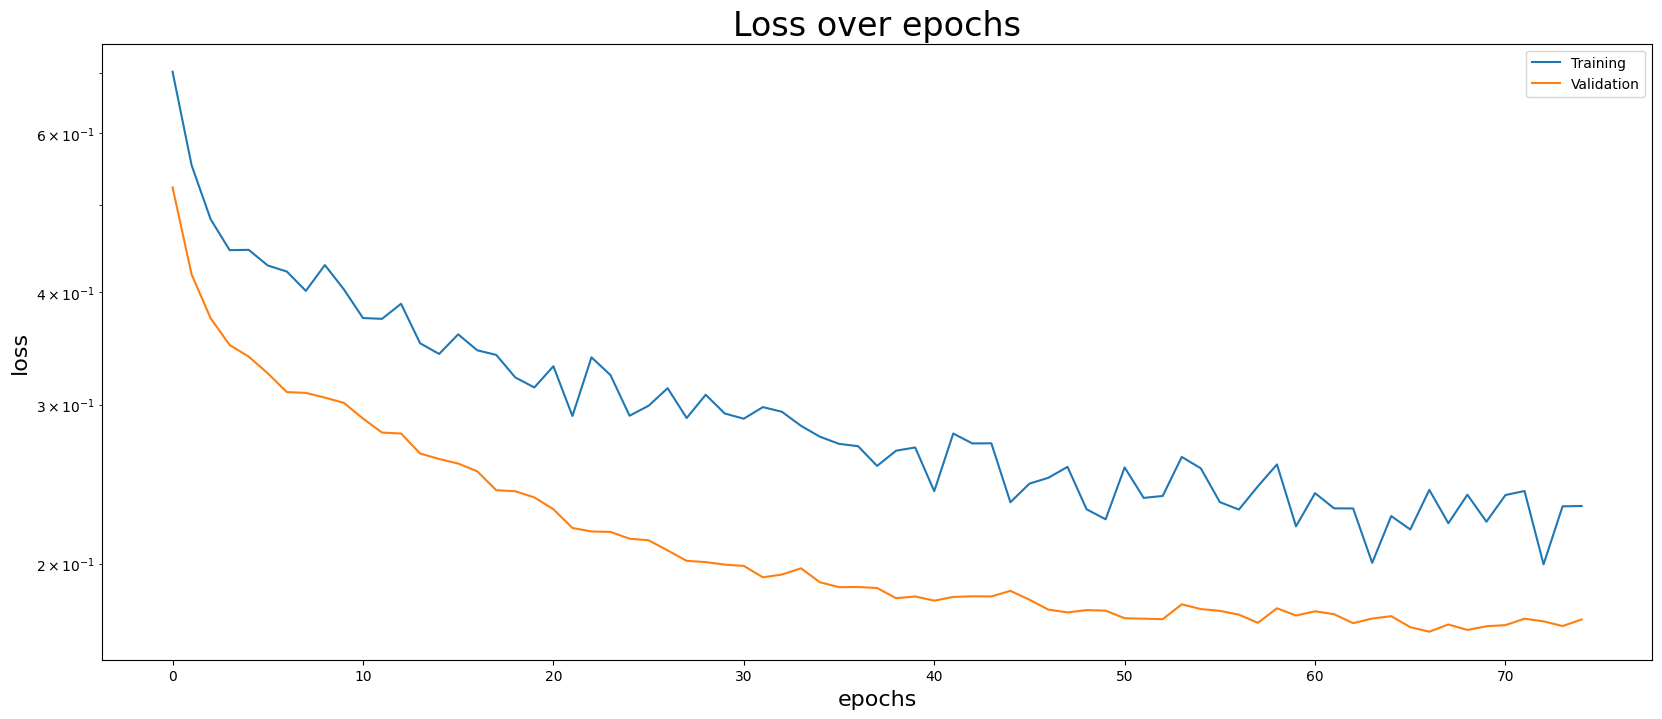

In [38]:
plt.yscale('log')
plt.ylabel("loss")
plt.xlabel("epochs")
plt.title('Loss over epochs')

plt.plot(history['loss']);
plt.plot(history['val_loss']);

plt.legend(['Training', 'Validation']);

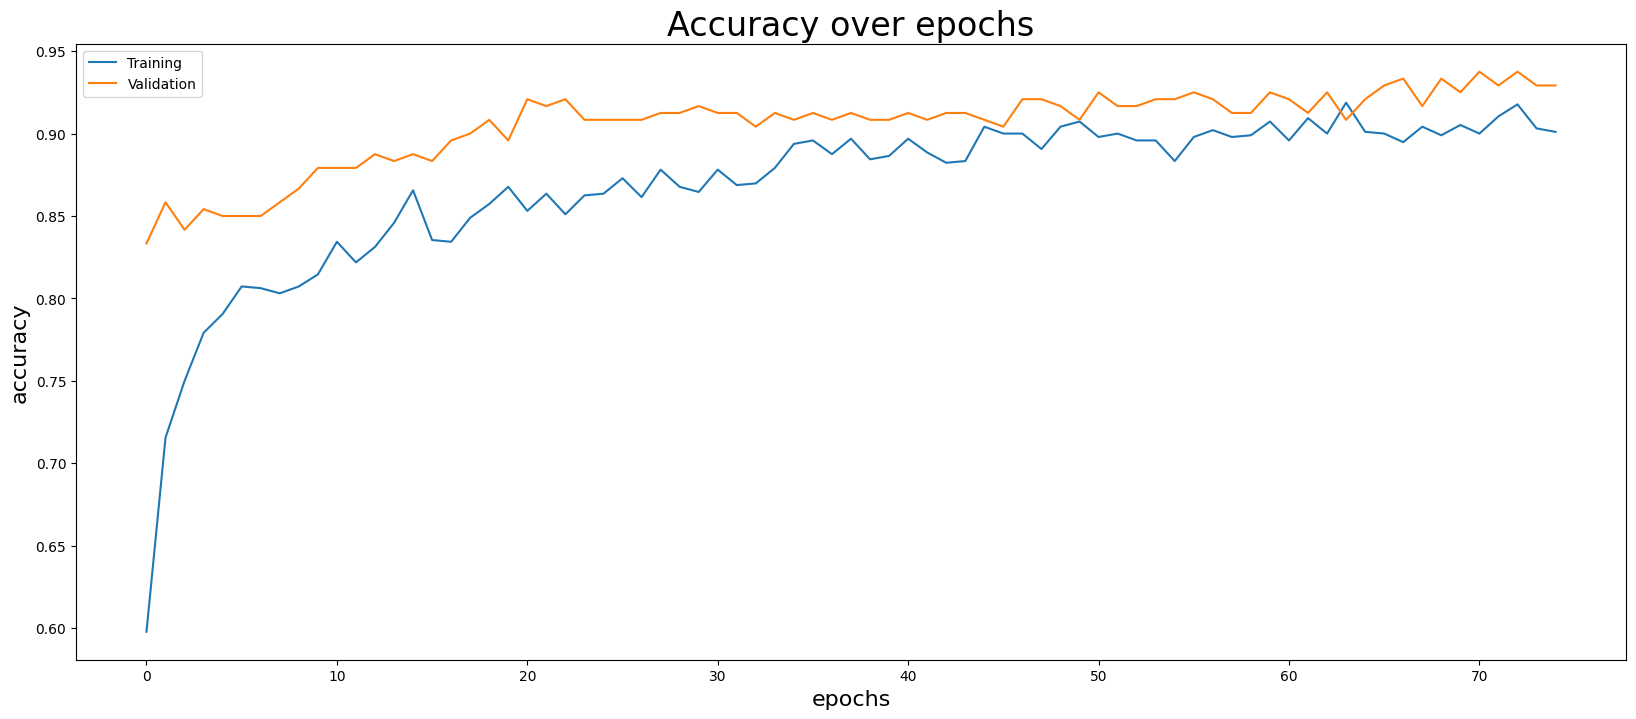

In [39]:
plt.ylabel("accuracy")
plt.xlabel("epochs")
plt.title('Accuracy over epochs')

plt.plot(history['accuracy'])
plt.plot(history['val_accuracy'])
plt.legend(['Training', 'Validation']);

In [40]:
val_accuracy = history['val_accuracy'][-1]
val_loss     = history['val_loss'][-1]

print(f"Final validation accuracy: {val_accuracy * 100:.2f}%")
val_loss, val_accuracy

Final validation accuracy: 92.92%


(0.1735254848996798, 0.9291666666666667)

In [41]:
train_eval_loader        = DataLoader(TensorDataset(X_train_t, y_train_t), batch_size=BATCH_SIZE)
train_loss, train_metric = evaluate_model(model, train_eval_loader)

print( train_loss, train_metric)

0.14757498641808828 0.9408333333333333


In [42]:

X_test_t = torch.tensor(X_test, dtype=torch.float32)
y_test_t = torch.tensor(y_test, dtype=torch.float32)

test_eval_loader       = DataLoader(TensorDataset(X_test_t, y_test_t), batch_size=BATCH_SIZE)
test_loss, test_metric = evaluate_model(model, test_eval_loader)

print( train_loss, train_metric)

0.14757498641808828 0.9408333333333333


# Schritt 4: Bewertung anhand technischer Metriken

## Spanne der Accuracy und Check auf Overfitting

Diese Invarianten beschreiben den erwarteten Arbeitsbereich des Modells.
Sie sind keine Optimierungsziele, sondern Leitplanken: Wenn spätere Änderungen
das Modell deutlich schlechter, verdächtig perfekt oder stark overfittet machen,
soll das Notebook hier sichtbar fehlschlagen.

In [43]:
# 85% is sufficient for our use case
assert train_metric > .85

In [44]:
assert test_metric > .85

In [45]:
assert abs(train_metric - test_metric) < .05

In [46]:
# we can not be too good, this would be a suspicious

assert test_metric < .95
assert train_metric < .95

## Verteilung der Vorhersage

In [47]:

def predict_proba(model, X):
    # Keras hatte predict(); in PyTorch kapseln wir Inferenz selbst.
    # eval() und no_grad() verhindern, dass Dropout aktiv bleibt oder unnötige Gradienten entstehen.
    model.eval()
    X_t = torch.tensor(X, dtype=torch.float32).to(device)
    with torch.no_grad():
        probabilities = torch.sigmoid(model(X_t))
    return probabilities.cpu().numpy()

threshold = .5
y_pred = (predict_proba(model, X) > threshold).astype("int32")
y_pred.shape

(1500,)

In [48]:
values, counts = np.unique(y_pred, return_counts=True)
values, counts

(array([0, 1], dtype=int32), array([819, 681]))

In [49]:
# equal distribution around classes expected
tolerance = 0.25
expected_count = len(X) / len(values)
lower_bound = int(expected_count * (1 - tolerance))
upper_bound = int(expected_count * (1 + tolerance))
print(f'{lower_bound}-{upper_bound}')

for count in counts:
    print(count)
    assert count in range(lower_bound, upper_bound)

562-937
819
681


# Schritt 5: Bewertung anhand von Business KPIs (Key Performance Indicator)

## Je nachdem wo man den Schnitt macht bekomt man andere Ergebnisse

In [50]:
def plot_proba_dist(X, y_true, threshold = 0.5, bins=25):

  y_hat = predict_proba(model, X).squeeze()

  TP_probabilities = y_hat[(y_true == 1) & (y_hat >= threshold)]
  FP_probabilities = y_hat[(y_true == 0) & (y_hat >= threshold)]
  TN_probabilities = y_hat[(y_true == 0) & (y_hat < threshold)]
  FN_probabilities = y_hat[(y_true == 1) & (y_hat < threshold)]

  plt.figure(figsize=(10, 6))

  plt.hist(TP_probabilities, bins=bins, range=(0,1), color='blue', alpha=0.3, label='TP (True Positives)')
  plt.hist(FP_probabilities, bins=bins, range=(0,1), color='red', alpha=0.5, label='FP (False Positives)')
  plt.hist(TN_probabilities, bins=bins, range=(0,1), color='orange', alpha=0.3, label='TN (True Negatives)')
  plt.hist(FN_probabilities, bins=bins, range=(0,1), color='gray', alpha=0.5, label='FN (False Negatives)')

  plt.axvline(threshold, color='green', linestyle='dashed', linewidth=2, label='Schwellenwert')

  plt.title('Verteilung der Wahrscheinlichkeiten')
  plt.xlabel('Wahrscheinlichkeit')
  plt.ylabel('Dichte')
  # plt.yscale('log')
  plt.legend()

  plt.grid(True)
  plt.tight_layout()
  plt.show()

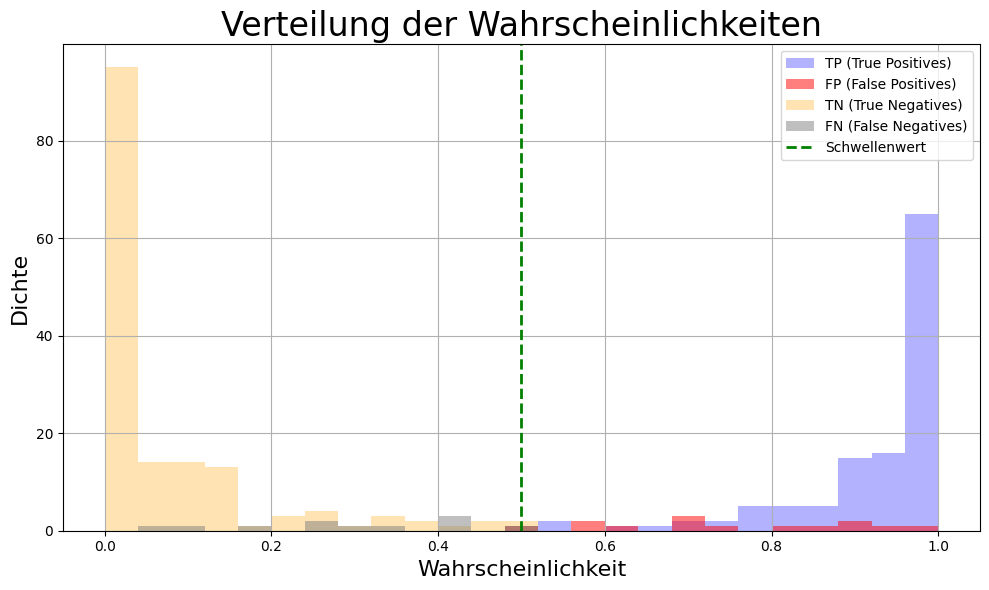

In [51]:
plot_proba_dist(X_test, y_test, threshold=0.5)

## Für Schnitt genau in der Mitte sieht es nicht so gut aus

In [52]:
y_true = y_test
threshold = .5

y_pred = (predict_proba(model, X_test) > threshold).astype("int32")
# y_pred = (base_clf.predict(X_test) > threshold).astype("int32")
y_true.shape, y_pred.shape

((300,), (300,))

In [53]:
from sklearn.metrics import confusion_matrix

# Calculate the confusion matrix
tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
tn, fp, fn, tp

(np.int64(155), np.int64(14), np.int64(11), np.int64(120))

In [54]:
# costs and benefits
cost_fp   = 5_000  # cost of a false positive
reward_tp = 1000   # reward of a true positive
cost_fn   = 1000   # cost of a false negative

kpi          = (tp * reward_tp) - (fp * cost_fp) - (fn * cost_fn)
kpi_per_case = round(kpi  / len(y_true))

print(f"KPI: ${kpi_per_case}")


KPI: $130


In [55]:
kpi               = (tp * reward_tp) - (fp * cost_fp)
kpi_per_insurance = round(kpi  / tp + fp)

print(f"KPI nur für Versicherte: ${kpi_per_insurance}")

KPI nur für Versicherte: $431


## Aber wir können den Schwellenwert verschieben und so die besten KPIs berechnen

In [56]:
# kpi depends on where we make the split between good and bad customers
def kpi_for_threshold(X, y_true, threshold, use_baseline=False):
    if use_baseline:
          y_pred = (base_clf.predict(X_test) > threshold).astype("int32")
    else:

      y_pred = (predict_proba(model, X) > threshold).astype("int32")

    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()

    kpi          = (tp * reward_tp) - (fp * cost_fp) - (fn * cost_fn)
    kpi_per_case = round(kpi  / len(y_true))
    return kpi_per_case, (tn, fp, fn, tp)

In [57]:
kpi_per_case, (tn, fp, fn, tp) = kpi_for_threshold(X_test, y_test, threshold=.5)
kpi_per_case, (tn, fp, fn, tp)

(130, (np.int64(155), np.int64(14), np.int64(11), np.int64(120)))

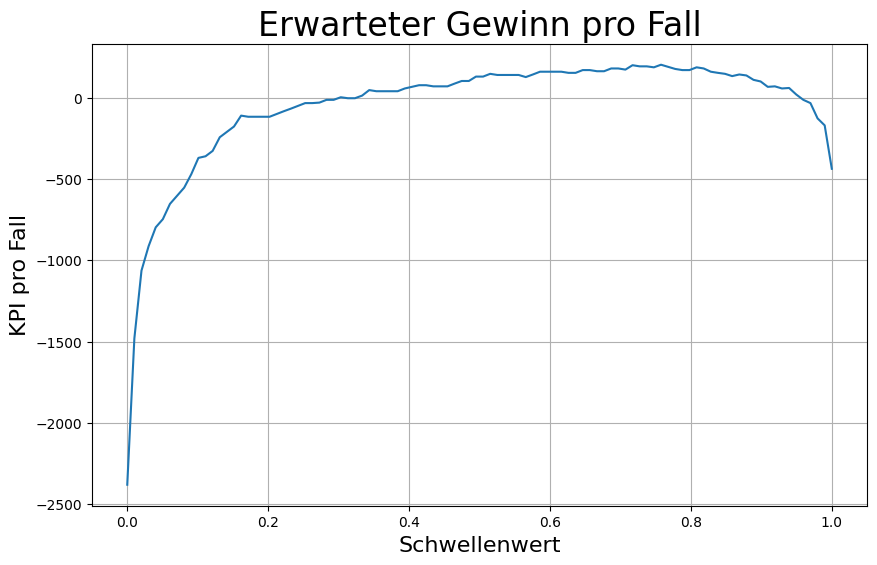

In [58]:
thresholds = np.linspace(0, 1, 100)
kpi_values = []

plt.figure(figsize=(10, 6))

# Calculate KPI for each threshold
for threshold in thresholds:
    kpi, _ = kpi_for_threshold(X_test, y_test, threshold)
    kpi_values.append(kpi)

# Plotting the results
plt.plot(thresholds, kpi_values)
plt.xlabel('Schwellenwert')
plt.ylabel('KPI pro Fall')
# plt.yscale('log')
plt.title('Erwarteter Gewinn pro Fall')
plt.grid(True)
plt.show()


In [59]:
best_kpi = max(kpi_values)
best_threshold = thresholds[np.array(kpi_values).argmax()]
_, (tn, fp, fn, tp) = kpi_for_threshold(X_test, y_test, best_threshold)
print(f"Best KPI ${best_kpi} for threshold {best_threshold}")
tn, fp, fn, tp

Best KPI $203 for threshold 0.7575757575757577


(np.int64(163), np.int64(6), np.int64(20), np.int64(111))

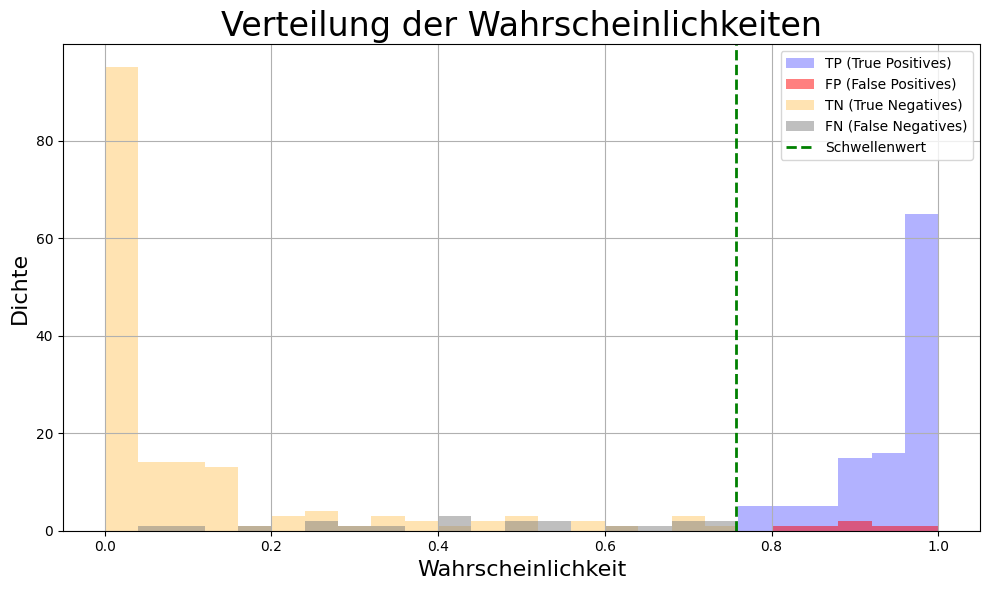

In [60]:
plot_proba_dist(X_test, y_test, threshold=best_threshold)

In [61]:
assert best_kpi > mimimum_profit_per_case

In [62]:
rate_people_getting_insurance = (tp + fp) / len(y_test)
rate_people_getting_insurance

np.float64(0.39)

In [63]:
assert rate_people_getting_insurance > minimun_insurance_rate

In [64]:
# Zusätzliche Tests
kpi_per_case = best_kpi
assert kpi_per_case > 150
assert rate_people_getting_insurance > 1/3    # mindestens ein Drittel
# assert rate_people_getting_insurance >= 0.40  # mehr als 40%

# Schritt 6: Modell sichern

In [65]:
# Modellverzeichnis anlegen, falls noch nicht vorhanden:
!mkdir -p ./models
# !ls -l ./models

# state_dict ist das übliche PyTorch-Speicherformat. Zusätzlich speichern wir die
# Architekturparameter, damit das Modell später eindeutig rekonstruiert werden kann.
model_path = './models/classifier-binary.pt'

torch.save({
    'model_state_dict': model.state_dict(),
    'num_features': num_features,
    'neurons_per_layer': neurons_per_layer,
    'dropout': dropout,
}, model_path)

In [66]:
# Optionaler Lesetest: So würde das gespeicherte Modell später wieder geladen.
# Das bleibt bewusst kurz, damit Speichern und Laden nicht an zwei inkompatiblen Stellen altern.
checkpoint = torch.load(model_path, map_location=device)
loaded_model = BinaryClassifier(
    num_features=checkpoint['num_features'],
    feature_mean=torch.zeros(checkpoint['num_features']),
    feature_std=torch.ones(checkpoint['num_features']),
    neurons_per_layer=checkpoint['neurons_per_layer'],
    dropout=checkpoint['dropout'],
).to(device)
loaded_model.load_state_dict(checkpoint['model_state_dict'])

print(loaded_model.eval())

summary(
    loaded_model,
    input_size=(1, 6),
    depth=10,
    col_names=("input_size", "output_size"),
)

BinaryClassifier(
  (network): Sequential(
    (0): Normalization()
    (1): Linear(in_features=6, out_features=100, bias=True)
    (2): ReLU()
    (3): BatchNorm1d(100, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (4): Dropout(p=0.7, inplace=False)
    (5): Linear(in_features=100, out_features=100, bias=True)
    (6): ReLU()
    (7): BatchNorm1d(100, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (8): Dropout(p=0.7, inplace=False)
    (9): Linear(in_features=100, out_features=1, bias=True)
  )
)


Layer (type:depth-idx)                   Input Shape               Output Shape
BinaryClassifier                         [1, 6]                    [1]
├─Sequential: 1-1                        [1, 6]                    [1, 1]
│    └─Normalization: 2-1                [1, 6]                    [1, 6]
│    └─Linear: 2-2                       [1, 6]                    [1, 100]
│    └─ReLU: 2-3                         [1, 100]                  [1, 100]
│    └─BatchNorm1d: 2-4                  [1, 100]                  [1, 100]
│    └─Dropout: 2-5                      [1, 100]                  [1, 100]
│    └─Linear: 2-6                       [1, 100]                  [1, 100]
│    └─ReLU: 2-7                         [1, 100]                  [1, 100]
│    └─BatchNorm1d: 2-8                  [1, 100]                  [1, 100]
│    └─Dropout: 2-9                      [1, 100]                  [1, 100]
│    └─Linear: 2-10                      [1, 100]                  [1, 1]
Total params: 11,30